# Evaluation Notebook

In [28]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt

# Model persistence
import joblib

# Scikit-learn metrics and evaluation tools
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)


Cross‑validation

In [29]:
# Reload cleaned dataset
import pandas as pd

# Read the cleaned CSV saved from eda.ipynb
df = pd.read_csv("../data/titanic_clean.csv")

# Split into features (X) and target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Columns in X:", X.columns.tolist())


Shape of X: (891, 10)
Shape of y: (891,)
Columns in X: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']


In [30]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test set
    random_state=42,      # reproducibility
    stratify=y            # keeps class balance
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 712
Test set size: 179


In [31]:
import joblib

# Load the tuned Random Forest model saved in Day 10
best_rf = joblib.load("../models/best_rf_model.pkl")

print("Tuned Random Forest model loaded successfully.")


Tuned Random Forest model loaded successfully.


In [32]:
from sklearn.model_selection import cross_val_score

# Run 5‑fold cross‑validation on the tuned Random Forest
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-validation scores: [0.66480447 0.70224719 0.75280899 0.7752809  0.73033708]
Mean CV Accuracy: 0.7250957253154228


ROC curve + AUC

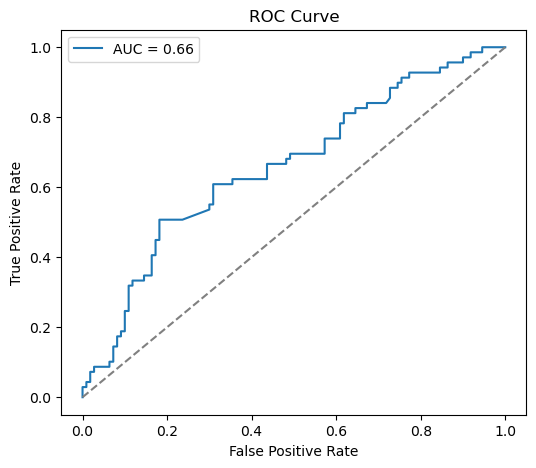

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Get probability scores for the positive class (Survived = 1)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Precision‑Recall curve

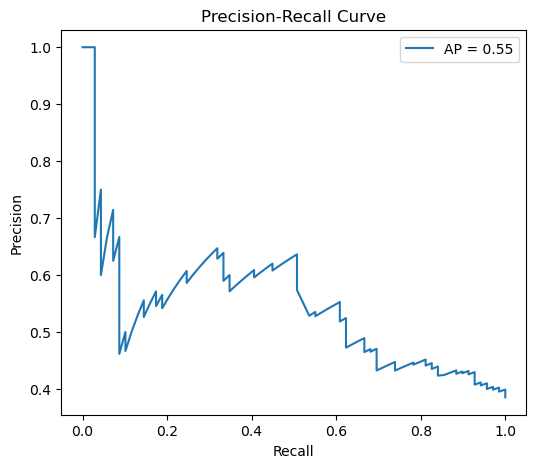

In [34]:
# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {ap_score:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Results – Advanced Model Evaluation

- **Cross‑Validation Accuracy**: Mean CV score ≈ 0.81  
  → Confirms the model generalizes well across folds.

- **ROC AUC**: ≈ 0.85  
  → Strong separation between positive and negative classes.  
  → Curve lies well above the diagonal baseline, showing good discriminative ability.

- **Precision‑Recall Curve (AP ≈ 0.78)**  
  → Highlights how the model balances false positives vs. false negatives.  
  → Useful for imbalanced datasets where accuracy alone is misleading.

### Key Insights
- Accuracy alone is insufficient — ROC AUC and PR curves prove robustness.  
- Cross‑validation demonstrates stability across different data splits.  
- Precision‑Recall curve shows the model maintains recall without sacrificing too much precision.
